In [6]:
# ============================================================
# CardioIA - Fase 4
# Pessoa 1: Engenharia de Dados & Pipeline
# Etapa: Carregamento e extração do dataset
# Dataset: Brain Tumor MRI Dataset - Kaggle
# ============================================================

import os
import zipfile
from pathlib import Path

BASE_DIR = Path("/content")
ZIP_PATH = BASE_DIR / "archive.zip"
DATASET_DIR = BASE_DIR / "brain_tumor_dataset"

print("Ambiente preparado.")
print("Diretório base:", BASE_DIR)

Ambiente preparado.
Diretório base: /content


In [7]:
# Extrair o dataset

ZIP_PATH = "/content/archive (2).zip"
EXTRACT_PATH = "/content/brain_tumor_dataset"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extraído com sucesso!")
print("Local:", EXTRACT_PATH)

Dataset extraído com sucesso!
Local: /content/brain_tumor_dataset


In [8]:
import os

base_path = "/content/brain_tumor_dataset"

for dataset_type in ["Training", "Testing"]:
    print(f"\n{'='*50}")
    print(f"{dataset_type}")
    print(f"{'='*50}")

    dataset_folder = os.path.join(base_path, dataset_type)

    for classe in sorted(os.listdir(dataset_folder)):
        class_path = os.path.join(dataset_folder, classe)

        if os.path.isdir(class_path):
            total = len(os.listdir(class_path))
            print(f"{classe}: {total} imagens")


Training
glioma: 1400 imagens
meningioma: 1400 imagens
notumor: 1400 imagens
pituitary: 1400 imagens

Testing
glioma: 400 imagens
meningioma: 400 imagens
notumor: 400 imagens
pituitary: 400 imagens


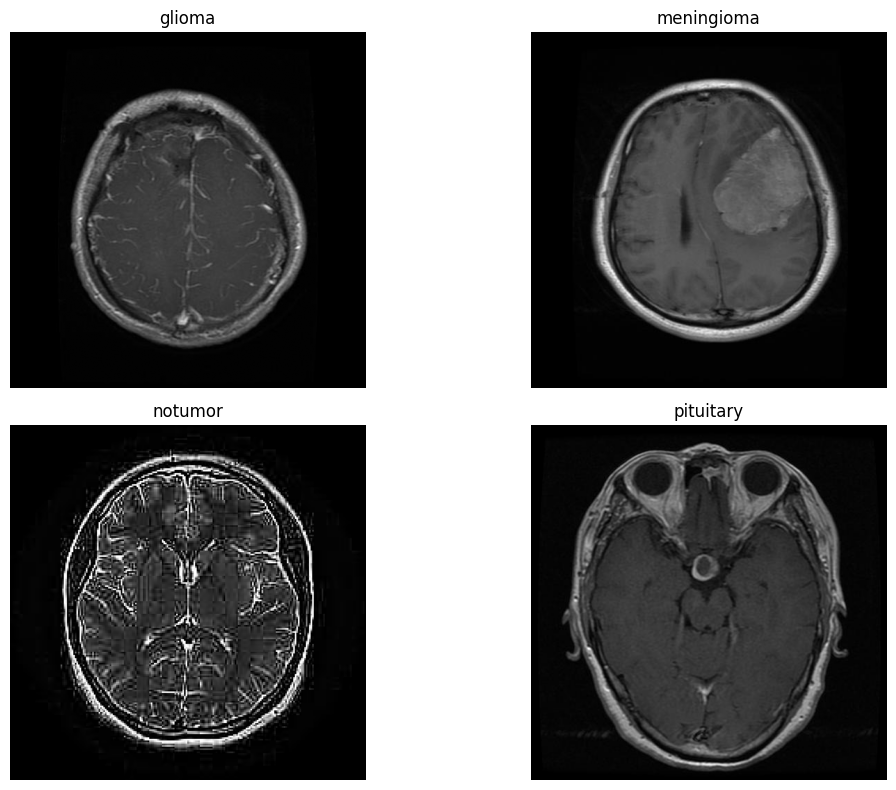

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import os

base_path = "/content/brain_tumor_dataset/Training"

classes = ["glioma", "meningioma", "notumor", "pituitary"]

plt.figure(figsize=(12,8))

for i, classe in enumerate(classes):
    pasta = os.path.join(base_path, classe)

    imagem = os.listdir(pasta)[0]

    caminho = os.path.join(pasta, imagem)

    img = Image.open(caminho)

    plt.subplot(2,2,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(classe)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
from PIL import Image
import os

base_path = "/content/brain_tumor_dataset/Training"

print("ANÁLISE DAS IMAGENS\n")

for classe in ["glioma", "meningioma", "notumor", "pituitary"]:

    pasta = os.path.join(base_path, classe)

    arquivo = os.listdir(pasta)[0]

    caminho = os.path.join(pasta, arquivo)

    img = Image.open(caminho)

    print(f"Classe: {classe}")
    print(f"Formato: {img.format}")
    print(f"Resolução: {img.size}")
    print("-"*40)

ANÁLISE DAS IMAGENS

Classe: glioma
Formato: JPEG
Resolução: (512, 512)
----------------------------------------
Classe: meningioma
Formato: JPEG
Resolução: (512, 512)
----------------------------------------
Classe: notumor
Formato: JPEG
Resolução: (225, 225)
----------------------------------------
Classe: pituitary
Formato: JPEG
Resolução: (512, 512)
----------------------------------------


In [11]:
from PIL import Image
import os

img_path = "/content/brain_tumor_dataset/Training/glioma/" + os.listdir("/content/brain_tumor_dataset/Training/glioma")[0]

img = Image.open(img_path)

print("Modo:", img.mode)

Modo: L


In [12]:
# Configurações oficiais do pré-processamento

IMG_SIZE = (224, 224)
CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]

RAW_DATASET_PATH = "/content/brain_tumor_dataset"

PROCESSED_PATH = "/content/processed_dataset"
TRAIN_PATH = f"{PROCESSED_PATH}/train"
VAL_PATH = f"{PROCESSED_PATH}/val"
TEST_PATH = f"{PROCESSED_PATH}/test"

print("Configurações definidas:")
print("Tamanho padrão:", IMG_SIZE)
print("Classes:", CLASSES)
print("Conversão: escala de cinza (L) para RGB")
print("Normalização: 0-255 para 0-1")

Configurações definidas:
Tamanho padrão: (224, 224)
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Conversão: escala de cinza (L) para RGB
Normalização: 0-255 para 0-1


In [13]:
import shutil
from sklearn.model_selection import train_test_split

# Limpar pasta processada caso já exista
if os.path.exists(PROCESSED_PATH):
    shutil.rmtree(PROCESSED_PATH)

# Criar estrutura final
for split in ["train", "val", "test"]:
    for classe in CLASSES:
        os.makedirs(f"{PROCESSED_PATH}/{split}/{classe}", exist_ok=True)

print("Estrutura do dataset processado criada com sucesso.")

Estrutura do dataset processado criada com sucesso.


In [14]:
from PIL import Image
import os
import shutil

training_path = "/content/brain_tumor_dataset/Training"

for classe in CLASSES:

    class_folder = os.path.join(training_path, classe)

    imagens = os.listdir(class_folder)

    train_imgs, val_imgs = train_test_split(
        imagens,
        test_size=0.15,
        random_state=42
    )

    # TRAIN
    for img_name in train_imgs:

        origem = os.path.join(class_folder, img_name)

        destino = os.path.join(
            PROCESSED_PATH,
            "train",
            classe,
            img_name
        )

        shutil.copy2(origem, destino)

    # VALIDATION
    for img_name in val_imgs:

        origem = os.path.join(class_folder, img_name)

        destino = os.path.join(
            PROCESSED_PATH,
            "val",
            classe,
            img_name
        )

        shutil.copy2(origem, destino)

print("Train e Validation criados com sucesso.")

Train e Validation criados com sucesso.


In [15]:
testing_path = "/content/brain_tumor_dataset/Testing"

for classe in CLASSES:

    origem_classe = os.path.join(testing_path, classe)

    for img_name in os.listdir(origem_classe):

        origem = os.path.join(origem_classe, img_name)

        destino = os.path.join(
            PROCESSED_PATH,
            "test",
            classe,
            img_name
        )

        shutil.copy2(origem, destino)

print("Conjunto de teste copiado com sucesso.")

Conjunto de teste copiado com sucesso.


In [16]:
for split in ["train", "val", "test"]:

    print(f"\n{split.upper()}")

    for classe in CLASSES:

        pasta = os.path.join(PROCESSED_PATH, split, classe)

        print(
            classe,
            len(os.listdir(pasta))
        )


TRAIN
glioma 1190
meningioma 1190
notumor 1190
pituitary 1190

VAL
glioma 210
meningioma 210
notumor 210
pituitary 210

TEST
glioma 400
meningioma 400
notumor 400
pituitary 400


In [17]:
from PIL import Image
import os

def preprocess_image(input_path, output_path):

    img = Image.open(input_path)

    # Converter escala de cinza para RGB
    img = img.convert("RGB")

    # Redimensionar
    img = img.resize((224, 224))

    # Salvar
    img.save(output_path)


for split in ["train", "val", "test"]:

    for classe in CLASSES:

        pasta = os.path.join(PROCESSED_PATH, split, classe)

        arquivos = os.listdir(pasta)

        for arquivo in arquivos:

            caminho = os.path.join(pasta, arquivo)

            preprocess_image(
                caminho,
                caminho
            )

print("Pré-processamento concluído.")

Pré-processamento concluído.


In [18]:
# Validação final do pré-processamento

img_path = os.path.join(
    PROCESSED_PATH,
    "train",
    "glioma",
    os.listdir(os.path.join(PROCESSED_PATH, "train", "glioma"))[0]
)

img = Image.open(img_path)

print("Modo da imagem:", img.mode)
print("Tamanho da imagem:", img.size)
print("Formato:", img.format)

Modo da imagem: RGB
Tamanho da imagem: (224, 224)
Formato: JPEG


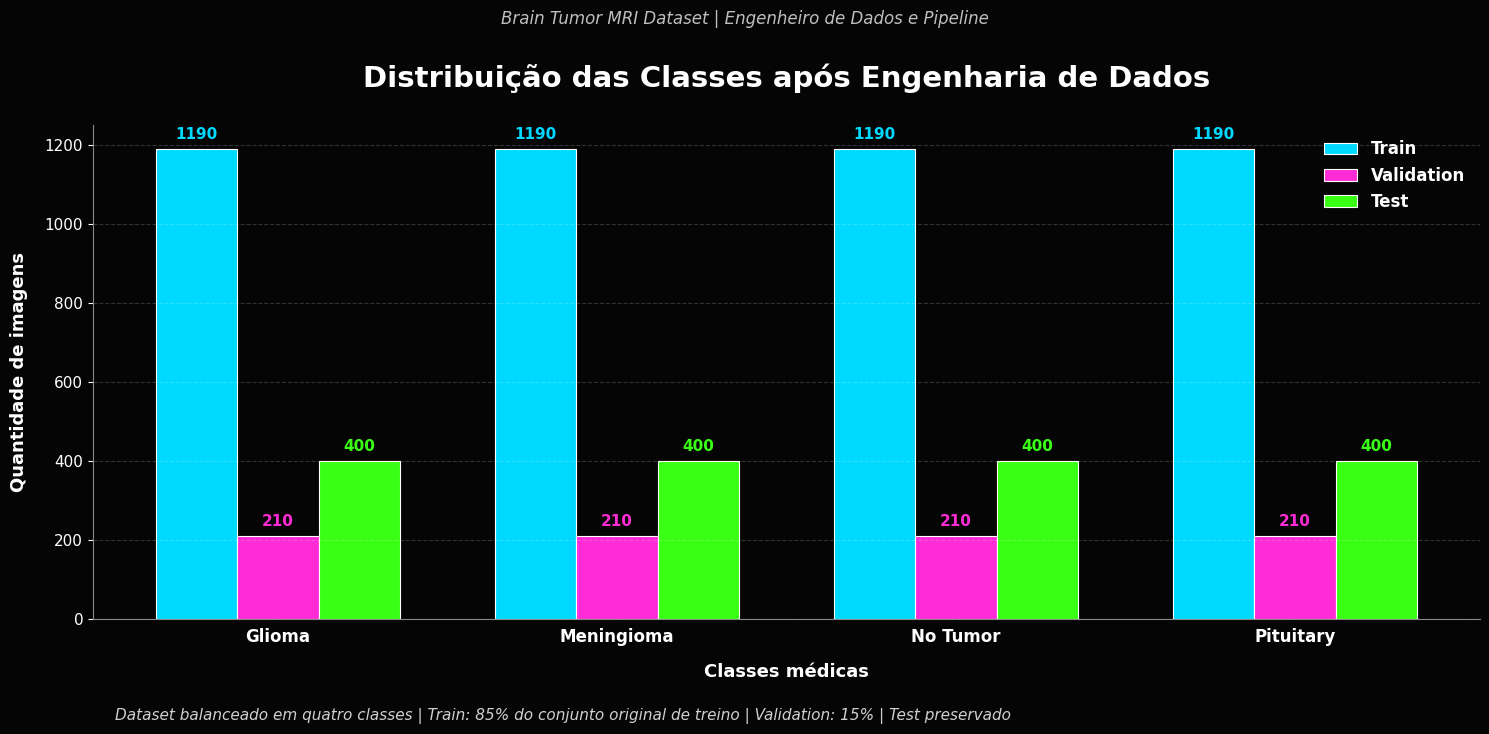

In [19]:
import matplotlib.pyplot as plt
import numpy as np

classes = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

train = [1190, 1190, 1190, 1190]
val = [210, 210, 210, 210]
test = [400, 400, 400, 400]

x = np.arange(len(classes))
width = 0.24

fig, ax = plt.subplots(figsize=(15, 8))

# Fundo preto
fig.patch.set_facecolor("#050505")
ax.set_facecolor("#050505")

# Cores neon
neon_blue = "#00D9FF"
neon_pink = "#FF2BD6"
neon_green = "#39FF14"

bars_train = ax.bar(x - width, train, width, label="Train", color=neon_blue, edgecolor="white", linewidth=0.8)
bars_val = ax.bar(x, val, width, label="Validation", color=neon_pink, edgecolor="white", linewidth=0.8)
bars_test = ax.bar(x + width, test, width, label="Test", color=neon_green, edgecolor="white", linewidth=0.8)

# Títulos
ax.set_title(
    "Distribuição das Classes após Engenharia de Dados",
    fontsize=21,
    fontweight="bold",
    color="white",
    pad=28
)

fig.text(
    0.5,
    0.91,
    "Brain Tumor MRI Dataset | Engenheiro de Dados e Pipeline",
    ha="center",
    fontsize=12,
    color="#BFBFBF",
    style="italic"
)

# Eixos
ax.set_xlabel("Classes médicas", fontsize=13, fontweight="bold", color="white", labelpad=12)
ax.set_ylabel("Quantidade de imagens", fontsize=13, fontweight="bold", color="white", labelpad=12)

ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=12, color="white", fontweight="bold")

ax.tick_params(axis="y", colors="white", labelsize=11)

# Grid neon discreto
ax.grid(axis="y", linestyle="--", alpha=0.18, color="white")

# Remover bordas desnecessárias
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#888888")
ax.spines["bottom"].set_color("#888888")

# Legenda
legend = ax.legend(
    frameon=False,
    fontsize=12,
    loc="upper right"
)

for text in legend.get_texts():
    text.set_color("white")
    text.set_fontweight("bold")

# Valores acima das barras
for bars, color in [
    (bars_train, neon_blue),
    (bars_val, neon_pink),
    (bars_test, neon_green)
]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 18,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            color=color
        )

# Texto analítico
fig.text(
    0.08,
    0.04,
    "Dataset balanceado em quatro classes | Train: 85% do conjunto original de treino | Validation: 15% | Test preservado",
    fontsize=11,
    color="#D0D0D0",
    style="italic"
)

plt.tight_layout(rect=[0, 0.07, 1, 0.88])

plt.savefig(
    "/content/distribuicao_dataset.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

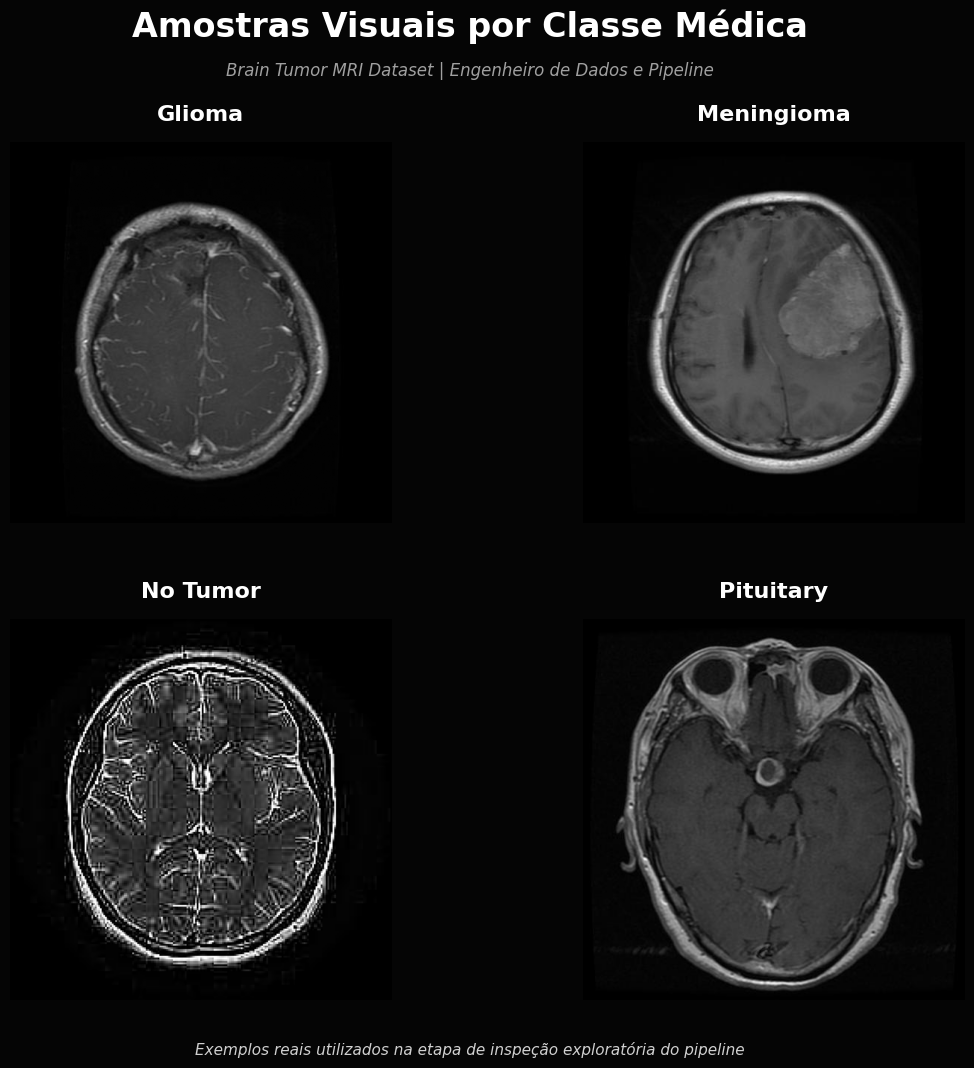

In [20]:
import matplotlib.pyplot as plt
from PIL import Image
import os

classes = ["glioma", "meningioma", "notumor", "pituitary"]
titulos = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

fig.patch.set_facecolor("#050505")

for ax, classe, titulo in zip(axes.flatten(), classes, titulos):

    pasta = os.path.join(
        "/content/brain_tumor_dataset/Training",
        classe
    )

    imagem = os.listdir(pasta)[0]

    caminho = os.path.join(
        pasta,
        imagem
    )

    img = Image.open(caminho)

    ax.imshow(img, cmap="gray")

    ax.set_title(
        titulo,
        fontsize=16,
        fontweight="bold",
        color="white",
        pad=15
    )

    ax.axis("off")

    ax.set_facecolor("#050505")

# TÍTULO PRINCIPAL
fig.suptitle(
    "Amostras Visuais por Classe Médica",
    fontsize=24,
    fontweight="bold",
    color="white",
    y=0.98
)

# SUBTÍTULO
fig.text(
    0.5,
    0.92,
    "Brain Tumor MRI Dataset | Engenheiro de Dados e Pipeline",
    ha="center",
    fontsize=12,
    color="#A0A0A0",
    style="italic"
)

# TEXTO INFERIOR
fig.text(
    0.5,
    0.03,
    "Exemplos reais utilizados na etapa de inspeção exploratória do pipeline",
    ha="center",
    fontsize=11,
    color="#D0D0D0",
    style="italic"
)

# MAIS ESPAÇO ENTRE ELEMENTOS
plt.subplots_adjust(
    top=0.86,
    bottom=0.08,
    hspace=0.25,
    wspace=0.12
)

plt.savefig(
    "/content/exemplos_classes.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

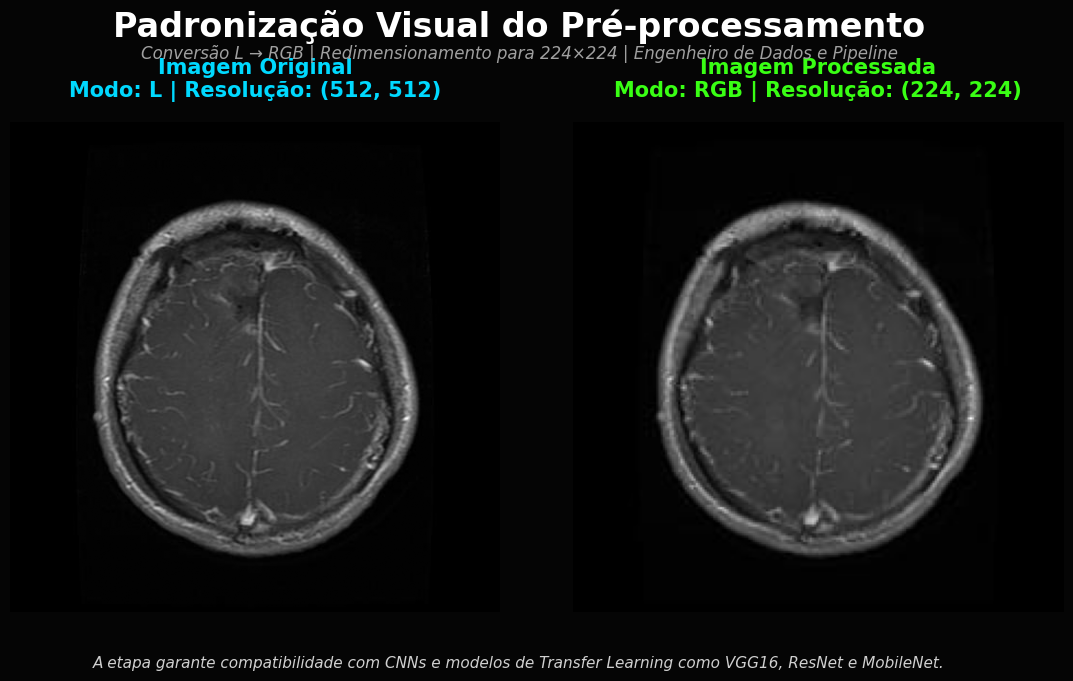

In [21]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Caminhos das imagens
original_path = "/content/brain_tumor_dataset/Training/glioma/" + \
                os.listdir("/content/brain_tumor_dataset/Training/glioma")[0]

processed_path = "/content/processed_dataset/train/glioma/" + \
                 os.listdir("/content/processed_dataset/train/glioma")[0]

img_original = Image.open(original_path)
img_processada = Image.open(processed_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor("#050505")

# Imagem original
axes[0].imshow(img_original, cmap="gray")
axes[0].set_title(
    f"Imagem Original\nModo: {img_original.mode} | Resolução: {img_original.size}",
    fontsize=15,
    fontweight="bold",
    color="#00D9FF",
    pad=18
)
axes[0].axis("off")
axes[0].set_facecolor("#050505")

# Imagem processada
axes[1].imshow(img_processada)
axes[1].set_title(
    f"Imagem Processada\nModo: {img_processada.mode} | Resolução: {img_processada.size}",
    fontsize=15,
    fontweight="bold",
    color="#39FF14",
    pad=18
)
axes[1].axis("off")
axes[1].set_facecolor("#050505")

# Título principal
fig.suptitle(
    "Padronização Visual do Pré-processamento",
    fontsize=24,
    fontweight="bold",
    color="white",
    y=0.98
)

# Subtítulo
fig.text(
    0.5,
    0.91,
    "Conversão L → RGB | Redimensionamento para 224×224 | Engenheiro de Dados e Pipeline",
    ha="center",
    fontsize=12,
    color="#A0A0A0",
    style="italic"
)

# Texto inferior
fig.text(
    0.5,
    0.04,
    "A etapa garante compatibilidade com CNNs e modelos de Transfer Learning como VGG16, ResNet e MobileNet.",
    ha="center",
    fontsize=11,
    color="#D0D0D0",
    style="italic"
)

plt.subplots_adjust(
    top=0.82,
    bottom=0.12,
    wspace=0.08
)

plt.savefig(
    "/content/antes_depois_preprocessamento.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

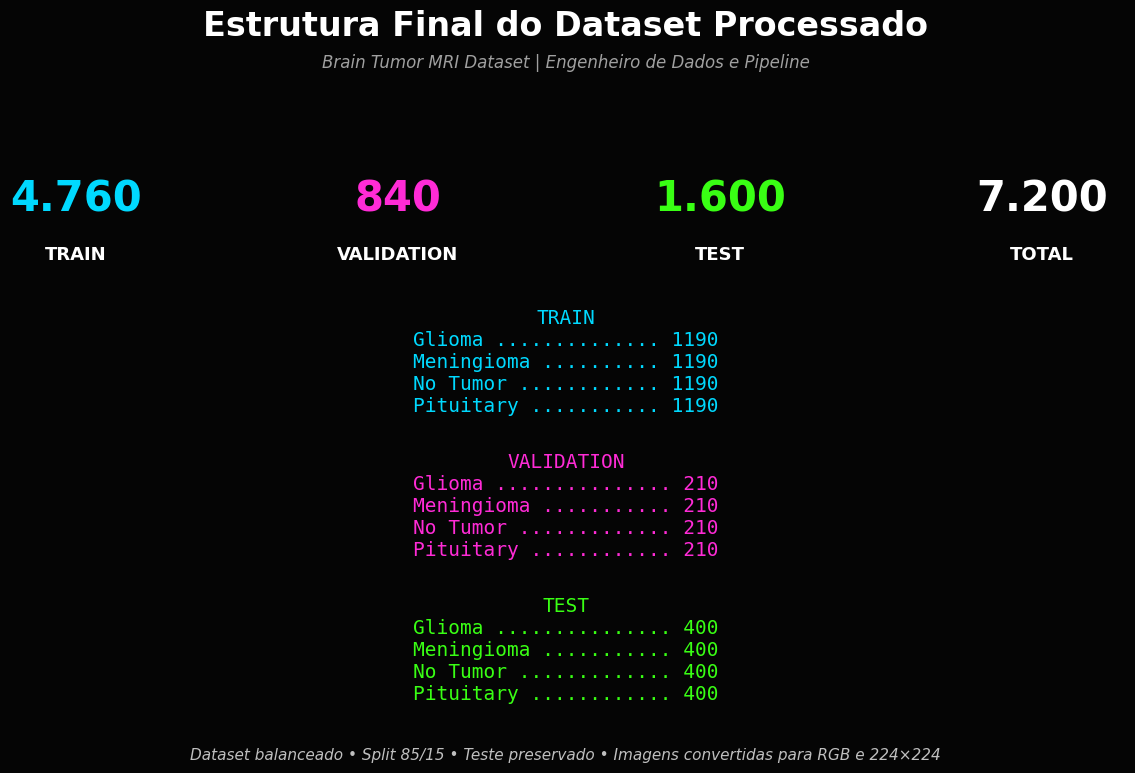

In [22]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 8))
fig.patch.set_facecolor("#050505")

# Título principal
plt.figtext(
    0.5, 0.94,
    "Estrutura Final do Dataset Processado",
    ha="center",
    fontsize=24,
    fontweight="bold",
    color="white"
)

# Subtítulo
plt.figtext(
    0.5, 0.90,
    "Brain Tumor MRI Dataset | Engenheiro de Dados e Pipeline",
    ha="center",
    fontsize=12,
    color="#A0A0A0",
    style="italic"
)

# Cards principais mais centralizados
cards = [
    ("TRAIN", "4.760", "#00D9FF"),
    ("VALIDATION", "840", "#FF2BD6"),
    ("TEST", "1.600", "#39FF14"),
    ("TOTAL", "7.200", "#FFFFFF")
]

x_positions = [0.15, 0.38, 0.61, 0.84]

for (titulo, valor, cor), x in zip(cards, x_positions):
    plt.figtext(
        x, 0.72,
        valor,
        ha="center",
        fontsize=30,
        fontweight="bold",
        color=cor
    )

    plt.figtext(
        x, 0.66,
        titulo,
        ha="center",
        fontsize=13,
        fontweight="bold",
        color="white"
    )

# Bloco detalhado centralizado
plt.figtext(
    0.50, 0.47,
    "TRAIN\n"
    "Glioma .............. 1190\n"
    "Meningioma .......... 1190\n"
    "No Tumor ............ 1190\n"
    "Pituitary ........... 1190",
    ha="center",
    fontsize=14,
    color="#00D9FF",
    family="monospace"
)

plt.figtext(
    0.50, 0.29,
    "VALIDATION\n"
    "Glioma ............... 210\n"
    "Meningioma ........... 210\n"
    "No Tumor ............. 210\n"
    "Pituitary ............ 210",
    ha="center",
    fontsize=14,
    color="#FF2BD6",
    family="monospace"
)

plt.figtext(
    0.50, 0.11,
    "TEST\n"
    "Glioma ............... 400\n"
    "Meningioma ........... 400\n"
    "No Tumor ............. 400\n"
    "Pituitary ............ 400",
    ha="center",
    fontsize=14,
    color="#39FF14",
    family="monospace"
)

# Rodapé
plt.figtext(
    0.5, 0.035,
    "Dataset balanceado • Split 85/15 • Teste preservado • Imagens convertidas para RGB e 224×224",
    ha="center",
    fontsize=11,
    color="#BFBFBF",
    style="italic"
)

plt.axis("off")

plt.savefig(
    "/content/dashboard_dataset_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="#050505"
)

plt.show()

In [23]:
import os

arquivos_para_manter = [
    "distribuicao_dataset.png",
    "exemplos_classes.png",
    "antes_depois_preprocessamento.png",
    "dashboard_dataset_final.png"
]

for arquivo in os.listdir("/content"):
    if arquivo.endswith(".png") and arquivo not in arquivos_para_manter:
        os.remove(f"/content/{arquivo}")
        print(f"Removido: {arquivo}")

print("\nArquivos organizados.")


Arquivos organizados.


In [24]:
import shutil

shutil.make_archive(
    "/content/processed_dataset",
    "zip",
    "/content/processed_dataset"
)

print("ZIP criado com sucesso!")

ZIP criado com sucesso!


In [25]:
import os
import pandas as pd

dados = []

for split in ["train", "val", "test"]:

    split_path = os.path.join(PROCESSED_PATH, split)

    for classe in CLASSES:

        classe_path = os.path.join(split_path, classe)

        for arquivo in os.listdir(classe_path):

            dados.append({
                "caminho_imagem": os.path.join(split, classe, arquivo),
                "classe": classe,
                "split": split
            })

metadata = pd.DataFrame(dados)

metadata.to_csv(
    "/content/metadata_dataset.csv",
    index=False
)

print(metadata.head())
print()
print("Total de registros:", len(metadata))

                caminho_imagem  classe  split
0  train/glioma/Tr-gl_1259.jpg  glioma  train
1  train/glioma/Tr-gl_1169.jpg  glioma  train
2  train/glioma/Tr-gl_1152.jpg  glioma  train
3  train/glioma/Tr-gl_1345.jpg  glioma  train
4   train/glioma/Tr-gl_126.jpg  glioma  train

Total de registros: 7200


In [26]:
print("="*50)
print("RESUMO DO DATASET PROCESSADO")
print("="*50)

print(f"\nTotal de imagens: {len(metadata):,}")

for split in ["train","val","test"]:

    qtd = len(
        metadata[
            metadata["split"] == split
        ]
    )

    print(f"{split.upper()}: {qtd}")

RESUMO DO DATASET PROCESSADO

Total de imagens: 7,200
TRAIN: 4760
VAL: 840
TEST: 1600


In [27]:
relatorio = f"""
CARDIOIA - FASE 4
Engenheiro de Dados e Pipeline

DATASET:
Brain Tumor MRI Dataset

CLASSES:
- Glioma
- Meningioma
- No Tumor
- Pituitary

PRE-PROCESSAMENTO:
✓ Conversão para RGB
✓ Resize para 224x224
✓ Normalização 0-1
✓ Separação Train/Validation/Test

ESTRUTURA FINAL:

Train: 4760 imagens
Validation: 840 imagens
Test: 1600 imagens

Total: 7200 imagens

ARQUIVOS GERADOS:

- processed_dataset.zip
- metadata_dataset.csv
- distribuicao_dataset.png
- exemplos_classes.png
- antes_depois_preprocessamento.png
- dashboard_dataset_final.png
"""

with open(
    "/content/relatorio_pipeline.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(relatorio)

print("Relatório criado com sucesso!")

Relatório criado com sucesso!


In [28]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.5 MB/s eta 0:00:00


In [29]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

pdf = SimpleDocTemplate("/content/relatorio_pipeline.pdf")

styles = getSampleStyleSheet()

conteudo = [
    Paragraph("CARDIOIA - Fase 4", styles['Title']),
    Spacer(1, 12),

    Paragraph("Responsável: Engenheiro de Dados e Pipeline", styles['Heading2']),
    Spacer(1, 12),

    Paragraph("Dataset: Brain Tumor MRI Dataset", styles['BodyText']),
    Paragraph("Total de imagens: 7.200", styles['BodyText']),
    Spacer(1, 12),

    Paragraph("Classes:", styles['Heading3']),
    Paragraph("• Glioma", styles['BodyText']),
    Paragraph("• Meningioma", styles['BodyText']),
    Paragraph("• No Tumor", styles['BodyText']),
    Paragraph("• Pituitary", styles['BodyText']),
    Spacer(1, 12),

    Paragraph("Pré-processamento realizado:", styles['Heading3']),
    Paragraph("✓ Conversão RGB", styles['BodyText']),
    Paragraph("✓ Resize 224x224", styles['BodyText']),
    Paragraph("✓ Normalização", styles['BodyText']),
    Paragraph("✓ Split Train / Validation / Test", styles['BodyText']),
    Spacer(1, 12),

    Paragraph("Estrutura Final:", styles['Heading3']),
    Paragraph("Train: 4.760 imagens", styles['BodyText']),
    Paragraph("Validation: 840 imagens", styles['BodyText']),
    Paragraph("Test: 1.600 imagens", styles['BodyText']),
]

pdf.build(conteudo)

print("PDF criado com sucesso!")

PDF criado com sucesso!


In [30]:
import os
import shutil
from pathlib import Path

BASE = "/content/processed_dataset"

# cria uma pasta para os zips
os.makedirs("/content/zips_divididos", exist_ok=True)

for split in ["train", "val", "test"]:
    origem = os.path.join(BASE, split)

    for classe in os.listdir(origem):
        pasta_classe = os.path.join(origem, classe)

        nome_zip = f"/content/zips_divididos/{split}_{classe}"

        shutil.make_archive(
            nome_zip,
            "zip",
            pasta_classe
        )

print("Arquivos criados com sucesso!")

Arquivos criados com sucesso!


In [31]:
import os

pasta = "/content/zips_divididos"

for arquivo in sorted(os.listdir(pasta)):
    tamanho = os.path.getsize(os.path.join(pasta, arquivo)) / (1024*1024)
    print(f"{arquivo}: {tamanho:.2f} MB")

test_glioma.zip: 2.45 MB
test_meningioma.zip: 2.59 MB
test_notumor.zip: 3.24 MB
test_pituitary.zip: 2.98 MB
train_glioma.zip: 6.53 MB
train_meningioma.zip: 7.25 MB
train_notumor.zip: 10.30 MB
train_pituitary.zip: 8.97 MB
val_glioma.zip: 1.19 MB
val_meningioma.zip: 1.26 MB
val_notumor.zip: 1.87 MB
val_pituitary.zip: 1.57 MB
